In [11]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# 1. Instance-Conditioned DistArc Loss (PROPOSAL A)
# ==========================================
class ProposalADistArcLoss(nn.Module):
    def __init__(self, in_features, out_features, m=0.4, lam=0.003, r_min=5.0, r_max=20.0, alignment_weight=0.1): 
        super(ProposalADistArcLoss, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.m = m
        self.lam = lam # Paper uses 0.003 for MNIST
        
        # Proposal A parameters
        self.r_min = r_min
        self.r_max = r_max
        self.alignment_weight = alignment_weight 
        
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        
        self.W = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.kaiming_uniform_(self.W)

    def forward(self, x, radii, labels):
        batch_size = x.size(0)
        
        # 1. Normalize embeddings and proxies
        x_norm = F.normalize(x, p=2, dim=1)
        W_norm = F.normalize(self.W, p=2, dim=0)
        
        # 2. Angular Cosine components
        cosine = torch.matmul(x_norm, W_norm).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
        target_logit = cosine[torch.arange(batch_size), labels]
        
        sine = torch.sqrt((1.0 - torch.pow(target_logit, 2)).clamp(min=1e-7))
        marginal_cosine = target_logit * self.cos_m - sine * self.sin_m 

        # ==========================================
        # PROPOSAL A: UNCERTAINTY ALIGNMENT
        # ==========================================
        # Calculate Epistemic Uncertainty based on angular confidence
        uncertainty = (1.0 - target_logit).detach() 
        
        # Normalize uncertainty across the batch (0.0 = simplest, 1.0 = most complex)
        u_norm = (uncertainty - uncertainty.min()) / (uncertainty.max() - uncertainty.min() + 1e-6)
        
        # Ideal Radius: Simple -> r_min, Complex -> r_max
        ideal_radii = self.r_min + (self.r_max - self.r_min) * u_norm
        
        # MSE Penalty to force the Radial Head to obey the topology
        alignment_loss = F.mse_loss(radii.squeeze(), ideal_radii)
        
        # ==========================================
        # DISTARC RADIAL/ANGULAR MATH 
        # ==========================================
        # Using instance-specific radii instead of static class radii
        radii_sq = torch.pow(radii, 2) 
        
        # Delta calculation (Euclidean distance squared approximation)
        dist_sq = 2.0 * radii_sq * (1.0 - cosine + 1e-6) 
        
        # DistArc Numerator and Denominator
        num_exp = marginal_cosine - (self.lam * dist_sq[torch.arange(batch_size), labels])
        
        denom_terms = cosine - (self.lam * dist_sq)
        denom_terms[torch.arange(batch_size), labels] = marginal_cosine - (self.lam * dist_sq[torch.arange(batch_size), labels])
        
        base_loss = -num_exp + torch.logsumexp(denom_terms, dim=1)
        
        # Final Loss = DistArc + Proposal A Enforcement
        return base_loss.mean() + (self.alignment_weight * alignment_loss)

    def predict(self, x):
        x_norm = F.normalize(x, p=2, dim=1)
        W_norm = F.normalize(self.W, p=2, dim=0)
        cosine = torch.matmul(x_norm, W_norm)
        return torch.argmax(cosine, dim=1)

# ==========================================
# 2. CNN with Predictive Radial Head
# ==========================================
class CNN_HyperSpaceX(nn.Module):
    def __init__(self, embedding_size=2, r_min=5.0, r_max=20.0):
        super(CNN_HyperSpaceX, self).__init__()
        
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), 
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), 
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)  
        )
        
        self.flatten_dim = 128 * 3 * 3
        
        self.fc = nn.Sequential(
            nn.Linear(self.flatten_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True)
        )
        
        # Angular Embedding (Original HyperSpaceX)
        self.projection = nn.Linear(256, embedding_size)
        
        # PROPOSAL A: Lightweight non-linear auxiliary network
        self.r_min = r_min
        self.r_max = r_max
        self.radial_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),
            nn.Sigmoid() 
        )
            
    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1) 
        features = self.fc(x)
        
        embeddings = self.projection(features)
        
        # Autonomously predict a continuous, instance-specific radius
        radii_pred = self.r_min + (self.r_max - self.r_min) * self.radial_head(features)
        
        return embeddings, radii_pred

# ==========================================
# 3. Data Loading & Training Boilerplate
# ==========================================
def get_dataloaders(batch_size):
    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=preprocess, download=True)
    val_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=preprocess, download=True)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader

def train_model(embedding_size=2, epochs=30, batch_size=256, lr=0.01):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    num_classes = 10 
    
    save_dir = './checkpoints'
    os.makedirs(save_dir, exist_ok=True)
    best_save_path = os.path.join(save_dir, 'best_proposal_a_mnist.pth')

    print(f"--- Starting Training: PROPOSAL A ---")
    model = CNN_HyperSpaceX(embedding_size=embedding_size).to(device)
    train_loader, val_loader = get_dataloaders(batch_size)

    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    
    # Paper uses lam=0.003, m=0.4 for MNIST
    criterion = ProposalADistArcLoss(in_features=embedding_size, out_features=num_classes, lam=0.003, m=0.4).to(device)
    optimizer = optim.SGD([{'params': model.parameters()}, {'params': criterion.parameters()}], lr=lr, weight_decay=5e-4, momentum=0.9)

    best_acc = 0.0

    for epoch in range(epochs):
        model.train()
        criterion.train()
        
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            embeddings, radii = model(images)
            loss = criterion(embeddings, radii, labels)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            torch.nn.utils.clip_grad_norm_(criterion.parameters(), 5.0)
            
            optimizer.step()
            running_loss += loss.item()
            pbar.set_postfix({'loss': f"{running_loss/len(train_loader):.4f}"})
            
        print(f"\nAvg Radius: {radii.mean().item():.2f} | Min: {radii.min().item():.2f} | Max: {radii.max().item():.2f}")

        model.eval()
        criterion.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                embeddings, radii = model(images)
                predicted = criterion.predict(embeddings)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        acc = 100 * correct / total
        print(f"Validation Accuracy: {acc:.2f}%\n")
        
        if acc > best_acc:
            best_acc = acc
            torch.save({'model_state_dict': model.state_dict()}, best_save_path)

if __name__ == '__main__':
    train_model(embedding_size=2, epochs=30)

--- Starting Training: PROPOSAL A ---


Epoch 1/30 [Train]: 100%|██████████| 235/235 [00:08<00:00, 27.18it/s, loss=2.1229]


Avg Radius: 5.44 | Min: 5.01 | Max: 9.09


Validation Accuracy: 89.36%



Epoch 2/30 [Train]: 100%|██████████| 235/235 [00:08<00:00, 27.06it/s, loss=1.7126]

...


Avg Radius: 5.37 | Min: 5.00 | Max: 9.21


Validation Accuracy: 90.78%



Epoch 30/30 [Train]: 100%|██████████| 235/235 [00:08<00:00, 27.26it/s, loss=1.6288]


Avg Radius: 5.50 | Min: 5.00 | Max: 11.29


Validation Accuracy: 91.20%



In [12]:
visualize_single_class_complexity(target_digit=9)

Saved Image Complexity grid to ./checkpoints/mnist_complexity_digit_9.png


In [13]:
digits_to_test = [4, 7, 8]

for digit in digits_to_test:
    print(f"--- Analyzing the '{digit}' Family ---")
    visualize_single_class_complexity(target_digit=digit)

--- Analyzing the '4' Family ---
Saved Image Complexity grid to ./checkpoints/mnist_complexity_digit_4.png
--- Analyzing the '7' Family ---
Saved Image Complexity grid to ./checkpoints/mnist_complexity_digit_7.png
--- Analyzing the '8' Family ---
Saved Image Complexity grid to ./checkpoints/mnist_complexity_digit_8.png


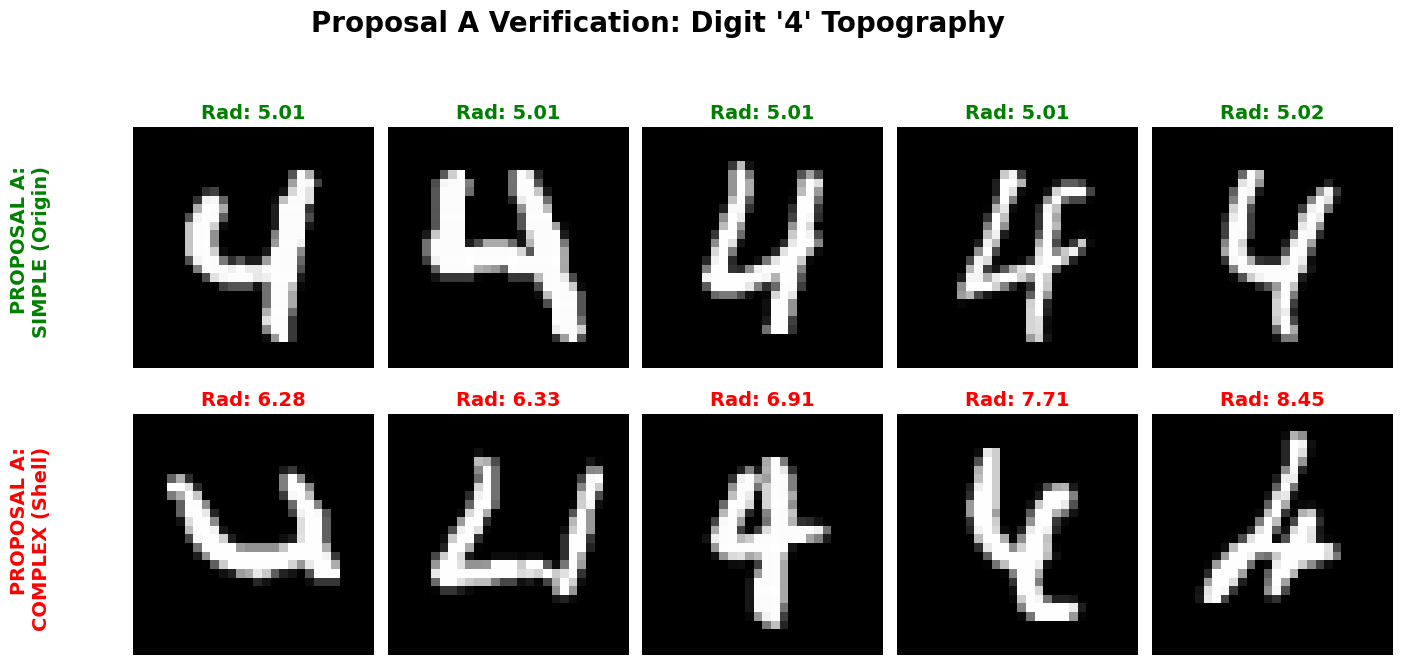

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def verify_proposal_a_topography(target_digit=9, checkpoint_path='./checkpoints/best_proposal_a_mnist.pth'):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # 1. Re-initialize model architecture
    model = CNN_HyperSpaceX(embedding_size=2).to(device)
    
    # 2. Load the Best Checkpoint
    if not os.path.exists(checkpoint_path):
        print(f"Error: Checkpoint not found at {checkpoint_path}")
        return
        
    checkpoint = torch.load(checkpoint_path, map_location=device)
    # Handle DataParallel prefix if necessary
    state_dict = {k.replace('module.', ''): v for k, v in checkpoint['model_state_dict'].items()}
    model.load_state_dict(state_dict)
    model.eval()

    # 3. Get a batch of 1024 validation images to find diverse examples
    _, val_loader = get_dataloaders(batch_size=1024)
    images, labels = next(iter(val_loader))
    
    # Filter for our target digit (e.g., just the 9s)
    mask = (labels == target_digit)
    images = images[mask].to(device)
    labels = labels[mask].to(device)

    # 4. Predict Radii
    with torch.no_grad():
        embeddings, radii = model(images)

    radii = radii.squeeze().cpu().numpy()
    images_np = images.cpu().numpy()

    # 5. Sort by radius to find the extremes
    sorted_indices = np.argsort(radii)
    simple_indices = sorted_indices[:5]   # Smallest radii (The Origin)
    complex_indices = sorted_indices[-5:] # Largest radii (The Outer Shell)

    # 6. Plotting
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    fig.suptitle(f"Proposal A Verification: Digit '{target_digit}' Topography", fontsize=20, fontweight='bold')

    # Top Row: SIMPLE / ANCHORED (Low Radius)
    for i, idx in enumerate(simple_indices):
        ax = axes[0, i]
        ax.imshow(images_np[idx].squeeze(), cmap='gray')
        ax.set_title(f"Rad: {radii[idx]:.2f}", color='green', fontsize=14, fontweight='bold')
        ax.axis('off')
        if i == 0:
            ax.text(-10, 14, "PROPOSAL A:\nSIMPLE (Origin)", fontsize=14, color='green', ha='right', va='center', rotation=90, fontweight='bold')

    # Bottom Row: COMPLEX / EXPELLED (High Radius)
    for i, idx in enumerate(complex_indices):
        ax = axes[1, i]
        ax.imshow(images_np[idx].squeeze(), cmap='gray')
        ax.set_title(f"Rad: {radii[idx]:.2f}", color='red', fontsize=14, fontweight='bold')
        ax.axis('off')
        if i == 0:
            ax.text(-10, 14, "PROPOSAL A:\nCOMPLEX (Shell)", fontsize=14, color='red', ha='right', va='center', rotation=90, fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(left=0.15, top=0.85)
    plt.show()

# Run the check for digit 9
verify_proposal_a_topography(target_digit=4)

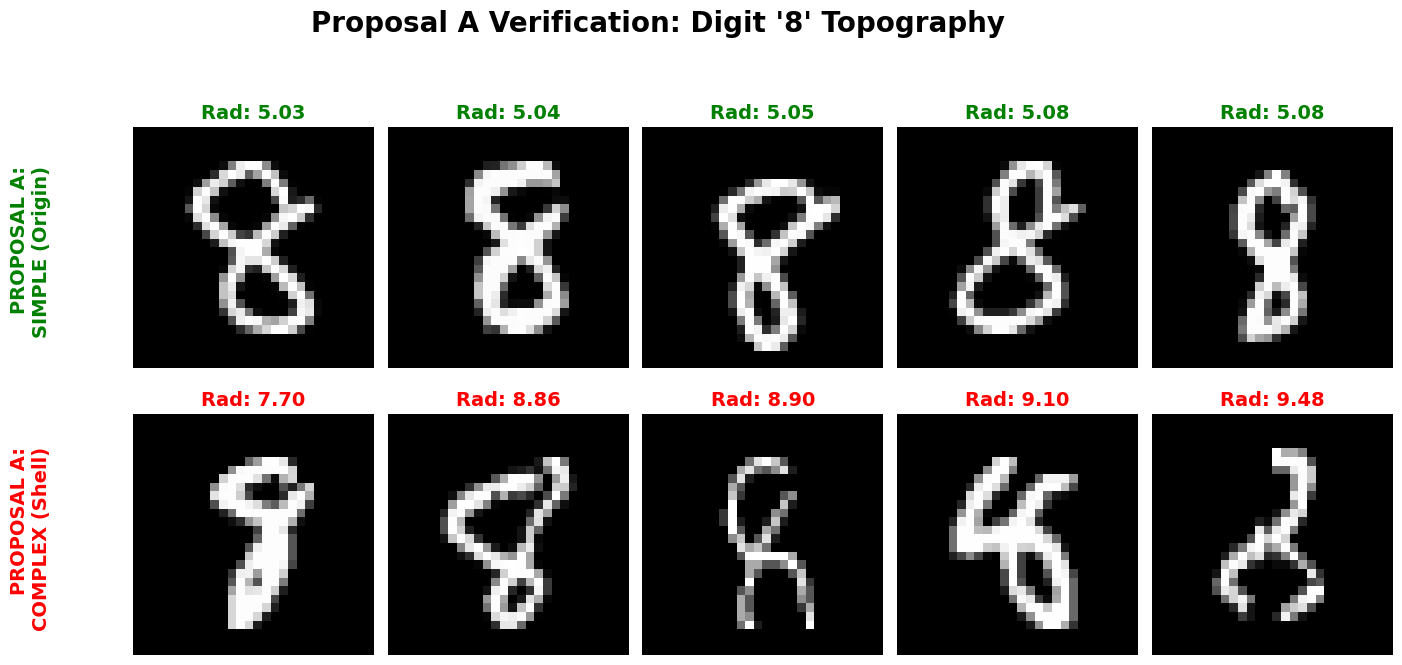

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def verify_proposal_a_topography(target_digit=9, checkpoint_path='./checkpoints/best_proposal_a_mnist.pth'):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # 1. Re-initialize model architecture
    model = CNN_HyperSpaceX(embedding_size=2).to(device)
    
    # 2. Load the Best Checkpoint
    if not os.path.exists(checkpoint_path):
        print(f"Error: Checkpoint not found at {checkpoint_path}")
        return
        
    checkpoint = torch.load(checkpoint_path, map_location=device)
    # Handle DataParallel prefix if necessary
    state_dict = {k.replace('module.', ''): v for k, v in checkpoint['model_state_dict'].items()}
    model.load_state_dict(state_dict)
    model.eval()

    # 3. Get a batch of 1024 validation images to find diverse examples
    _, val_loader = get_dataloaders(batch_size=1024)
    images, labels = next(iter(val_loader))
    
    # Filter for our target digit (e.g., just the 9s)
    mask = (labels == target_digit)
    images = images[mask].to(device)
    labels = labels[mask].to(device)

    # 4. Predict Radii
    with torch.no_grad():
        embeddings, radii = model(images)

    radii = radii.squeeze().cpu().numpy()
    images_np = images.cpu().numpy()

    # 5. Sort by radius to find the extremes
    sorted_indices = np.argsort(radii)
    simple_indices = sorted_indices[:5]   # Smallest radii (The Origin)
    complex_indices = sorted_indices[-5:] # Largest radii (The Outer Shell)

    # 6. Plotting
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    fig.suptitle(f"Proposal A Verification: Digit '{target_digit}' Topography", fontsize=20, fontweight='bold')

    # Top Row: SIMPLE / ANCHORED (Low Radius)
    for i, idx in enumerate(simple_indices):
        ax = axes[0, i]
        ax.imshow(images_np[idx].squeeze(), cmap='gray')
        ax.set_title(f"Rad: {radii[idx]:.2f}", color='green', fontsize=14, fontweight='bold')
        ax.axis('off')
        if i == 0:
            ax.text(-10, 14, "PROPOSAL A:\nSIMPLE (Origin)", fontsize=14, color='green', ha='right', va='center', rotation=90, fontweight='bold')

    # Bottom Row: COMPLEX / EXPELLED (High Radius)
    for i, idx in enumerate(complex_indices):
        ax = axes[1, i]
        ax.imshow(images_np[idx].squeeze(), cmap='gray')
        ax.set_title(f"Rad: {radii[idx]:.2f}", color='red', fontsize=14, fontweight='bold')
        ax.axis('off')
        if i == 0:
            ax.text(-10, 14, "PROPOSAL A:\nCOMPLEX (Shell)", fontsize=14, color='red', ha='right', va='center', rotation=90, fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(left=0.15, top=0.85)
    plt.show()

# Run the check for digit 9
verify_proposal_a_topography(target_digit=8)